In [1]:
from copy import deepcopy
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mysklearn.mypytable import MyPyTable
from mysklearn.myutils import *

/home/damon/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
data = MyPyTable().load_from_file("input_data/plate-data-normal.csv")

norm_matrix = np.array([r[:-1] for r in data.data])

In [3]:
tev = {}
reduced_datasets = {}

for k in range(1, norm_matrix.shape[1]+1):
    covariance_matrix = np.cov(norm_matrix, ddof = 1, rowvar = False)

    eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

    # np.argsort can only provide lowest to highest; use [::-1] to reverse the list
    order_of_importance = np.argsort(eigenvalues)[::-1] 

    # utilize the sort order to sort eigenvalues and eigenvectors
    sorted_eigenvalues = eigenvalues[order_of_importance]
    sorted_eigenvectors = eigenvectors[:,order_of_importance]

    explained_variance = sorted_eigenvalues / np.sum(sorted_eigenvalues)

    reduced_data = np.matmul(norm_matrix, sorted_eigenvectors[:,:k])
    reduced_datasets[k] = reduced_data

    total_explained_variance = sum(explained_variance[:k])
    tev[k] = total_explained_variance

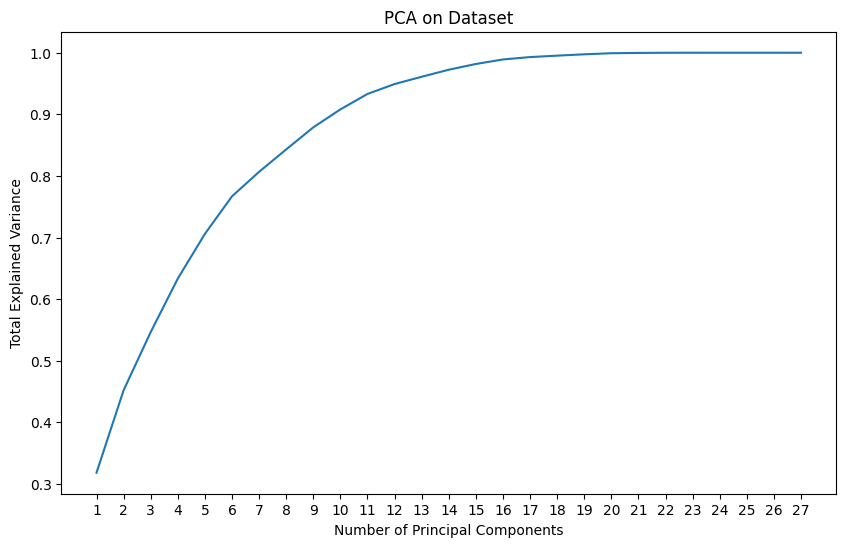

In [4]:
plt.figure(figsize=(10,6))
sns.lineplot(x=list(tev.keys()), y=list(tev.values()))
plt.xticks(list(tev.keys()))
plt.xlabel("Number of Principal Components")
plt.ylabel("Total Explained Variance")
plt.title("PCA on Dataset")
plt.show()

In [7]:
pca_data = MyPyTable(
    [f"att{i}" for i in range(10)] + ["Class"], 
          [list(reduced_datasets[10][i]) + [data.data[i][-1]] for i in range(len(data.data))]
)

pca_data.save_to_file("input_data/plate-data-pca.csv")